In [14]:
import sys
sys.path.insert(0, '../Week-5-6-7-8')

import json
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR, NuSVR
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from tqdm import tqdm

from helpers.modeling import identify_column_types, create_preprocessor, evaluate_model
from uncertainty import conformal_quantile, build_intervals, calibration_table

with open('../Week-5-6-7-8/results.json', 'r') as f:
    results = json.load(f)

df = pd.read_csv("../Datasets/processed/UHPC_dataset/semantic_recoding_features_50_with_publications.csv")

In [15]:
target_col = 'cs_28d'
pub_col    = 'paper_reference'
threshold  = 50
alpha      = 0.90

X = df.drop(columns=[target_col, pub_col])
y = df[target_col]

# Preprocessor template — cloned fresh for every pipeline fit inside the loop
numerical_cols, one_hot_cols, k_fold_cols = identify_column_types(X)
preprocessor_template = create_preprocessor(numerical_cols, one_hot_cols, k_fold_cols,
                                             handle_unknown='ignore')

model_configs = [
    ('knn',   KNeighborsRegressor, 'knn'),
    ('svr',   SVR,                 'svr'),
    ('nusvr', NuSVR,               'nusvr'),
]

selected_pubs = [
    pub for pub, grp in df.groupby(pub_col) if len(grp) >= threshold
]
print(f"Publications with >= {threshold} rows: {len(selected_pubs)} / {df[pub_col].nunique()}")

Publications with >= 50 rows: 6 / 165


In [16]:
all_intervals = []

for pub_id in tqdm(selected_pubs):
    test_mask = df[pub_col] == pub_id
    X_te = X[test_mask]
    y_te = y[test_mask]

    X_tr_all = X[~test_mask]
    y_tr_all = y[~test_mask]

    # Hold out 15 % of training as calibration set for conformal interval
    X_tr_fit, X_cal, y_tr_fit, y_cal = train_test_split(
        X_tr_all, y_tr_all, test_size=0.15, random_state=42
    )

    for model_name, model_cls, param_key in model_configs:
        params = results["best_params"]["recoded_50"][param_key]
        pipeline = Pipeline([
            ('preprocessor', clone(preprocessor_template)),
            ('model',        model_cls()),
        ])
        pipeline.set_params(**params)
        pipeline.fit(X_tr_fit, y_tr_fit)

        q = conformal_quantile(pipeline, X_cal, y_cal, alpha)
        row_df = build_intervals(
            pipeline, X_te, y_te,
            pd.Series([pub_id] * len(X_te), name='publication'),
            q, X_tr_fit
        )
        row_df['model'] = model_name
        all_intervals.append(row_df)

logo_intervals = pd.concat(all_intervals, ignore_index=True)
print(f"Total predicted rows: {len(logo_intervals)}")
logo_intervals.head()

100%|██████████| 6/6 [00:17<00:00,  2.86s/it]

Total predicted rows: 1356


,publication,prediction,true,lower,upper,residual,mean_distance,model
0,Ref-121-Research,169.708655,159.0,141.142563,198.274748,10.708655,11.078859,knn
1,Ref-121-Research,129.082200,173.0,100.516107,157.648292,43.917800,7.917982,knn
2,Ref-121-Research,167.659270,159.0,139.093178,196.225363,8.659270,7.086053,knn
3,Ref-121-Research,164.544628,150.0,135.978535,193.110721,14.544628,12.377914,knn
4,Ref-121-Research,148.258692,134.0,119.692600,176.824785,14.258692,8.575108,knn


In [17]:
# Pooled metrics per model across all LOGO folds
for model_name in ['knn', 'svr', 'nusvr']:
    df_m = logo_intervals[logo_intervals['model'] == model_name]
    rmse = np.sqrt((df_m['residual'] ** 2).mean())
    mae  = df_m['residual'].mean()
    cov  = ((df_m['true'] >= df_m['lower']) & (df_m['true'] <= df_m['upper'])).mean()
    w    = (df_m['upper'] - df_m['lower']).mean()
    print(f"{model_name.upper():6s} | RMSE={rmse:.2f}  MAE={mae:.2f}  Coverage={cov:.2%}  Avg Width={w:.2f}")

KNN    | RMSE=28.67  MAE=22.60  Coverage=66.81%  Avg Width=52.57
SVR    | RMSE=34.31  MAE=26.49  Coverage=55.31%  Avg Width=45.70
NUSVR  | RMSE=34.46  MAE=26.66  Coverage=55.31%  Avg Width=46.11


In [18]:
# Per-publication calibration table — KNN
cal_logo_knn = calibration_table(
    logo_intervals[logo_intervals['model'] == 'knn']
)
cal_logo_knn

,publication,n_rows,mean_true,mean_prediction,coverage,interval_width,mean_residual,mean_distance
0,Ref-121-Research,80,165.075000,173.617380,0.800000,57.132186,19.918325,8.982105
1,Ref-139-Research,51,134.101961,135.772031,0.686275,54.651835,20.900684,10.912043
2,Ref-141-Research,73,132.506849,120.768166,0.876712,50.784839,14.942703,12.424799
3,Ref-144-Research,112,157.053571,163.378522,0.705357,48.585899,19.179749,5.943147
4,Ref-48-Research,72,188.104167,159.038360,0.291667,50.962069,36.723047,20.088522
5,Ref-85-Research,64,173.250000,152.099919,0.609375,56.052071,26.149759,6.400313


In [19]:
# Per-publication calibration table — SVR
cal_logo_svr = calibration_table(
    logo_intervals[logo_intervals['model'] == 'svr']
)
cal_logo_svr

,publication,n_rows,mean_true,mean_prediction,coverage,interval_width,mean_residual,mean_distance
0,Ref-121-Research,80,165.075000,159.488343,0.700000,50.508690,20.135035,3.797615
1,Ref-139-Research,51,134.101961,142.837525,0.666667,40.897877,18.363003,4.251526
2,Ref-141-Research,73,132.506849,124.207257,0.917808,47.494419,11.960671,4.926943
3,Ref-144-Research,112,157.053571,163.596257,0.660714,43.576627,19.039156,2.453522
4,Ref-48-Research,72,188.104167,144.973626,0.111111,44.362042,54.145969,7.936465
5,Ref-85-Research,64,173.250000,133.821982,0.171875,46.702847,39.428018,2.603497


In [20]:
# Per-publication calibration table — NuSVR
cal_logo_nusvr = calibration_table(
    logo_intervals[logo_intervals['model'] == 'nusvr']
)
cal_logo_nusvr

,publication,n_rows,mean_true,mean_prediction,coverage,interval_width,mean_residual,mean_distance
0,Ref-121-Research,80,165.075000,159.330209,0.725000,50.778547,19.974710,3.796980
1,Ref-139-Research,51,134.101961,142.795420,0.705882,42.387531,18.397552,4.250443
2,Ref-141-Research,73,132.506849,128.763434,0.904110,49.516159,12.268948,4.847955
3,Ref-144-Research,112,157.053571,167.074207,0.616071,43.466995,20.439155,2.454746
4,Ref-48-Research,72,188.104167,144.446338,0.111111,45.476507,54.845089,7.932761
5,Ref-85-Research,64,173.250000,136.084713,0.203125,44.725083,37.165287,2.601290


In [21]:
poor_coverage_threshold = 0.90

poor_coverage_logo = pd.concat([
    cal_logo_knn.assign(model='knn'),
    cal_logo_svr.assign(model='svr'),
    cal_logo_nusvr.assign(model='nusvr'),
])
poor_coverage_logo = (
    poor_coverage_logo[poor_coverage_logo['coverage'] < poor_coverage_threshold]
    .sort_values('coverage')
    [['model', 'publication', 'n_rows', 'coverage', 'interval_width', 'mean_residual', 'mean_distance']]
    .reset_index(drop=True)
)

print(f"Publications below {poor_coverage_threshold:.0%} coverage: {poor_coverage_logo['publication'].nunique()} unique, {len(poor_coverage_logo)} model-publication pairs")
poor_coverage_logo

Publications below 90% coverage: 6 unique, 16 model-publication pairs


,model,publication,n_rows,coverage,interval_width,mean_residual,mean_distance
0,nusvr,Ref-48-Research,72,0.111111,45.476507,54.845089,7.932761
1,svr,Ref-48-Research,72,0.111111,44.362042,54.145969,7.936465
2,svr,Ref-85-Research,64,0.171875,46.702847,39.428018,2.603497
3,nusvr,Ref-85-Research,64,0.203125,44.725083,37.165287,2.601290
4,knn,Ref-48-Research,72,0.291667,50.962069,36.723047,20.088522
5,knn,Ref-85-Research,64,0.609375,56.052071,26.149759,6.400313
6,nusvr,Ref-144-Research,112,0.616071,43.466995,20.439155,2.454746
7,svr,Ref-144-Research,112,0.660714,43.576627,19.039156,2.453522
8,svr,Ref-139-Research,51,0.666667,40.897877,18.363003,4.251526
9,knn,Ref-139-Research,51,0.686275,54.651835,20.900684,10.912043


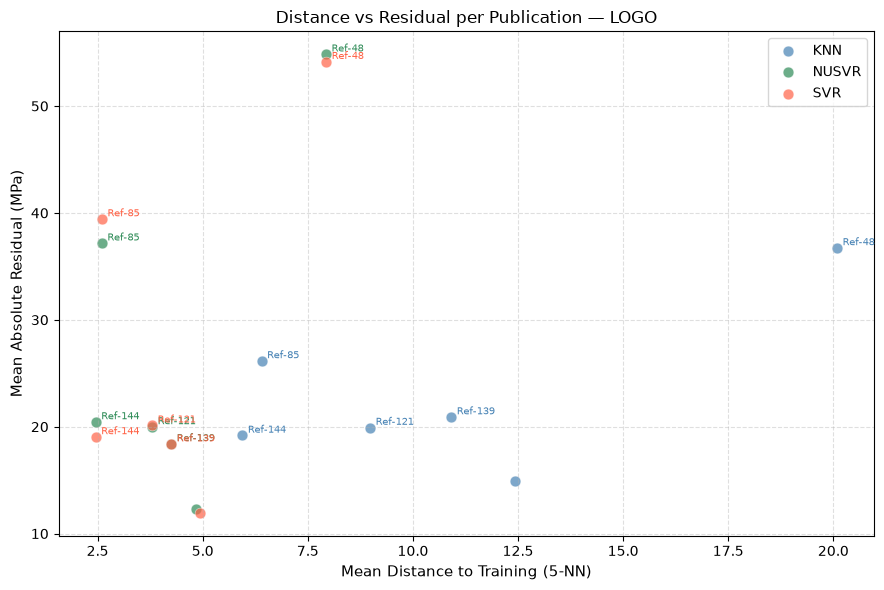

In [22]:
import matplotlib.pyplot as plt

all_cal_logo = pd.concat([
    cal_logo_knn.assign(model='knn'),
    cal_logo_svr.assign(model='svr'),
    cal_logo_nusvr.assign(model='nusvr'),
], ignore_index=True)

colors = {'knn': 'steelblue', 'svr': 'tomato', 'nusvr': 'seagreen'}

fig, ax = plt.subplots(figsize=(9, 6))

for model_name, grp in all_cal_logo.groupby('model'):
    ax.scatter(grp['mean_distance'], grp['mean_residual'],
               label=model_name.upper(), color=colors[model_name],
               alpha=0.7, edgecolors='white', linewidths=0.4, s=60)

for model_name, grp in all_cal_logo.groupby('model'):
    for _, row in grp.nlargest(5, 'mean_residual').iterrows():
        ax.annotate(row['publication'].replace('-Research', '').replace('-data', ''),
                    xy=(row['mean_distance'], row['mean_residual']),
                    fontsize=7, color=colors[model_name],
                    xytext=(4, 2), textcoords='offset points')

ax.set_xlabel('Mean Distance to Training (5-NN)', fontsize=11)
ax.set_ylabel('Mean Absolute Residual (MPa)', fontsize=11)
ax.set_title('Distance vs Residual per Publication — LOGO', fontsize=12)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

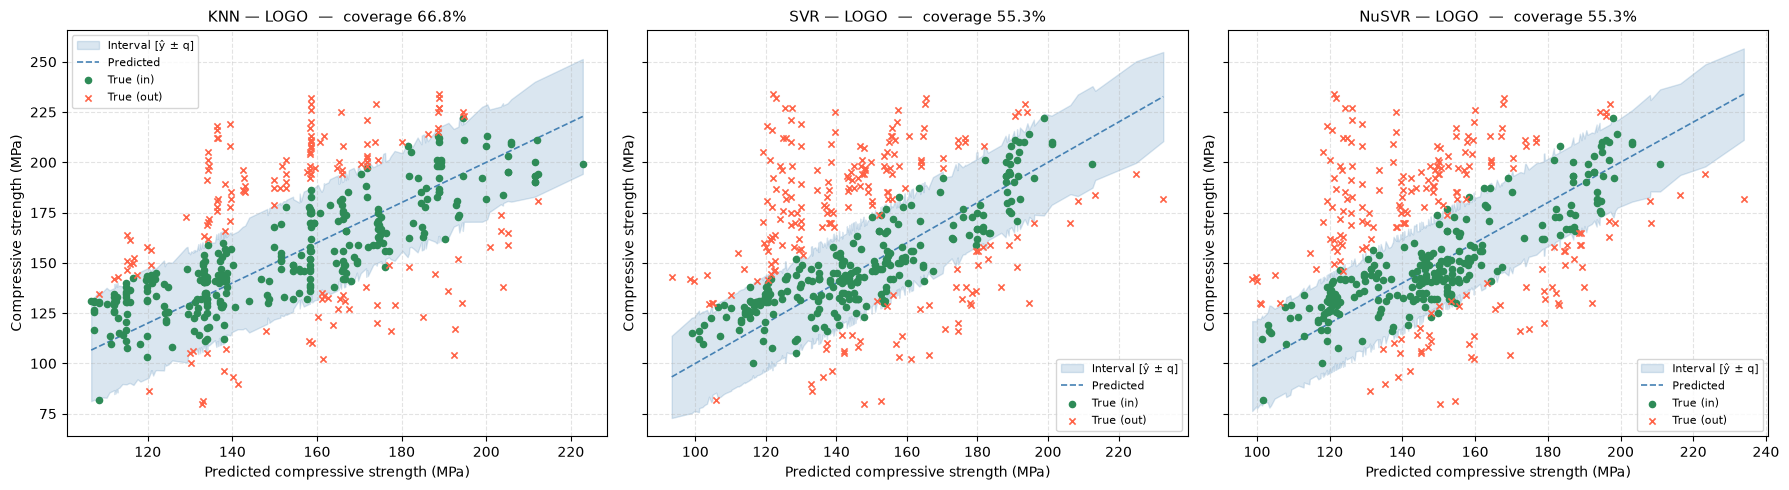

In [23]:
from uncertainty import plot_interval_band

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, model_name, label in zip(axes, ["knn", "svr", "nusvr"], ["KNN", "SVR", "NuSVR"]):
    plot_interval_band(
        logo_intervals[logo_intervals["model"] == model_name],
        f"{label} — LOGO",
        ax=ax,
    )
plt.tight_layout()
plt.show()